In [1]:
!pip install numpy matplotlib scikit-fuzzy scipy networkx

## Import libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

## Universe variables

In [3]:
temperature = ctrl.Antecedent(np.arange(0, 51, 1), 'temperature')
humidity = ctrl.Antecedent(np.arange(0, 101, 1), 'humidity')
fan_speed = ctrl.Consequent(np.arange(0, 101, 1), 'fan_speed')

In [4]:
temperature

Antecedent: temperature

In [5]:
temperature.universe

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50])

In [6]:
humidity

Antecedent: humidity

In [7]:
humidity.universe

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100])

In [8]:
fan_speed

Consequent: fan_speed

In [9]:
fan_speed.universe

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100])

## Create membership functions

In [10]:
temperature.automf(3, names=['cold', 'medium', 'hot'])
humidity.automf(3, names=['low', 'medium', 'high'])

fan_speed['low'] = fuzz.trimf(fan_speed.universe, [0, 0, 50])
fan_speed['medium'] = fuzz.trimf(fan_speed.universe, [0, 50, 100])
fan_speed['high'] = fuzz.trimf(fan_speed.universe, [50, 100, 100])

## View The Functions

/home/stark/projects/fuzzy/venv/lib/python3.10/site-packages/skfuzzy/control/fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


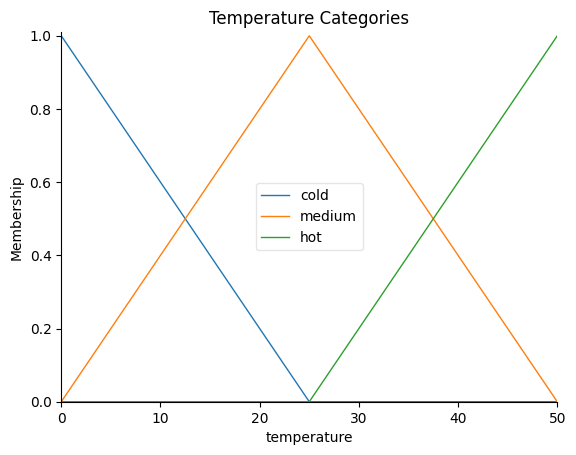

In [11]:
temperature.view()
plt.title('Temperature Categories')
plt.show()

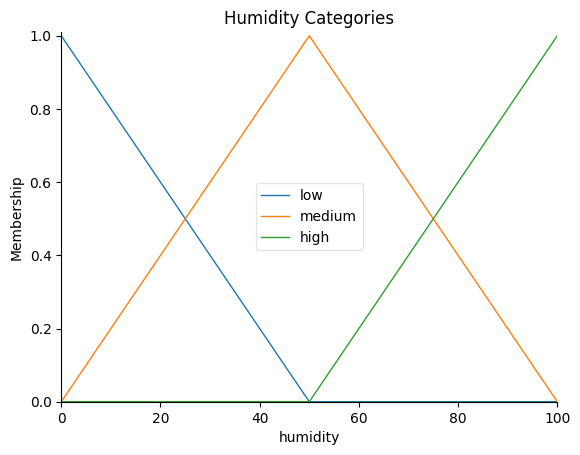

In [12]:
humidity.view()
plt.title('Humidity Categories')
plt.show()

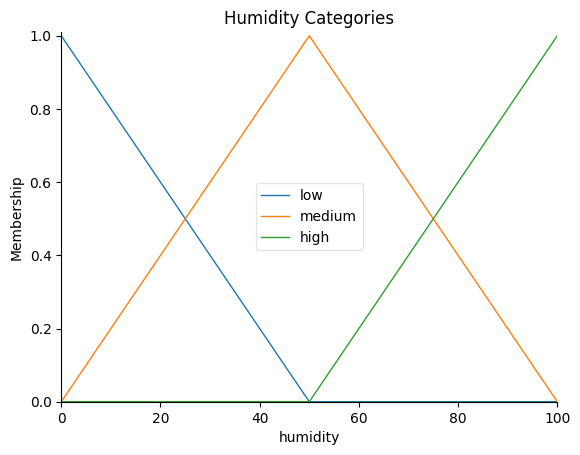

In [13]:
humidity.view()
plt.title('Humidity Categories')
plt.show()

## Define rules
- If temperature is hot OR humidity is high, then fan speed is high.

- If temperature is medium AND humidity is medium, then fan speed is medium.

- If temperature is cold, then fan speed is low.

In [14]:
rule1 = ctrl.Rule(temperature['hot'] | humidity['high'], fan_speed['high'])
rule2 = ctrl.Rule(temperature['medium'] & humidity['medium'], fan_speed['medium'])
rule3 = ctrl.Rule(temperature['cold'], fan_speed['low'])

## Create control system

In [15]:

fan_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])
fan_system = ctrl.ControlSystemSimulation(fan_ctrl)

## Simulate the Fuzzy System

Fan Speed: 58.78%


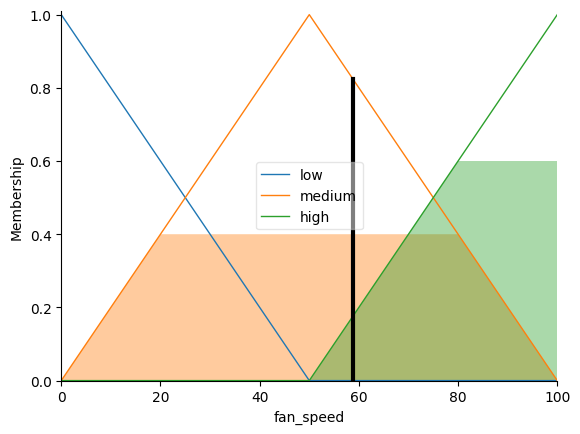

In [16]:
fan_system.input['temperature'] = 35
fan_system.input['humidity'] = 80
fan_system.compute()

print(f"Fan Speed: {fan_system.output['fan_speed']:.2f}%")
fan_speed.view(sim=fan_system)
plt.show()

In [17]:
temp_hot = fuzz.interp_membership(temperature.universe, temperature['hot'].mf, 35)
humidity_high = fuzz.interp_membership(humidity.universe, humidity['high'].mf, 80)

print(f"Temperature 'Hot' Membership: {temp_hot:.2f}")
print(f"Humidity 'High' Membership: {humidity_high:.2f}")

Temperature 'Hot' Membership: 0.40
Humidity 'High' Membership: 0.60
